# APIS to nnUnet data format

# Importación de librerías y funciones auxiliares

In [1]:
import SimpleITK as sitk
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import shutil
import pandas as pd
from tqdm import tqdm

In [2]:
i=0

In [4]:
input_dir = "D:/jm.rivera/APIS/train_000/train_000_ncct.nii.gz"
masks_dir = "D:/jm.rivera/APIS/train_000/masks/train_000_r1_mask.nii.gz"
dataset_id="APIS"
output_dir = f"D:/jm.rivera/nnUnet_data/nnUNet_raw/Dataset005_{dataset_id}/"
imagesTr = os.path.join(output_dir, "imagesTr") 
labelsTr = os.path.join(output_dir, "labelsTr")

In [5]:
os.makedirs(output_dir, exist_ok=True)
os.makedirs(imagesTr, exist_ok=True)
os.makedirs(labelsTr, exist_ok=True)

In [10]:
img_path = '019'
original_path = f"D:/jm.rivera/APIS/train_{img_path[-3:]}/train_{img_path[-3:]}_ncct.nii.gz"
mask_path = f"D:/jm.rivera/APIS/train_{img_path[-3:]}/masks/train_{img_path[-3:]}_r1_mask.nii.gz"

ct = sitk.ReadImage(original_path)
mask = sitk.ReadImage(mask_path)

print(img_path)

assert(ct.GetSize() == mask.GetSize())
assert(np.allclose(ct.GetSpacing(), mask.GetSpacing()))
print(ct.GetOrigin())
print(mask.GetOrigin())
# assert(np.allclose(ct.GetOrigin(), mask.GetOrigin()))
print(ct.GetDirection())
print(mask.GetDirection())
assert(np.allclose(ct.GetDirection(), mask.GetDirection(), atol=1e-4))

019
(-111.27444458007812, 27.219512939453125, -132.82582092285156)
(-103.97223663330078, 81.22996520996094, -99.74650573730469)
(0.999977175889585, -0.0066323910462418745, 0.0012880558588908855, -0.006632391118312039, -0.9272870285499695, 0.37429236908648494, 0.00128805587752828, 0.374292369775257, 0.9273098529379115)
(0.9967431213676314, -0.044290192251928456, -0.06739085404647954, -0.03325296794909587, -0.9870576073414242, 0.15688059471943222, 0.07346693221366662, 0.1541287080971941, 0.9853156609895954)


AssertionError: 

In [12]:
for idx, img_path in enumerate(os.listdir("D:/jm.rivera/APIS/")):

    original_path = f"D:/jm.rivera/APIS/train_{img_path[-3:]}/train_{img_path[-3:]}_ncct.nii.gz"
    mask_path = f"D:/jm.rivera/APIS/train_{img_path[-3:]}/masks/train_{img_path[-3:]}_r1_mask.nii.gz"

    ct = sitk.ReadImage(original_path)
    mask = sitk.ReadImage(mask_path)

    print(img_path)
    if(img_path[-3:] != "019"):
        assert(ct.GetSize() == mask.GetSize())
        assert(np.allclose(ct.GetSpacing(), mask.GetSpacing(), atol=1e-4))
        assert(np.allclose(ct.GetOrigin(), mask.GetOrigin(), atol=1e-4))
        assert(np.allclose(ct.GetDirection(), mask.GetDirection(), atol=1e-4))

train_000
train_001
train_002
train_003
train_004
train_005
train_006
train_007
train_008
train_009
train_010
train_011
train_012
train_013
train_014
train_015
train_016
train_017
train_018
train_019
train_020
train_021
train_022
train_023
train_024
train_025
train_026
train_027
train_028
train_029
train_030
train_031
train_032
train_033
train_034
train_035
train_036
train_037
train_038
train_039
train_040
train_041
train_042
train_043
train_044
train_045
train_046
train_047
train_048
train_049
train_050
train_051
train_052
train_053
train_054
train_055
train_056
train_057
train_058
train_059


In [39]:
for idx, img_path in enumerate(os.listdir(imagesTr), start=1):

    case_id = f"{dataset_id}_{idx:03d}"
    original_path = f"{imagesTr}/{img_path}"
    mask_path = os.path.join(labelsTr, f"{case_id}.nii.gz")

    ct = sitk.ReadImage(original_path)
    mask = sitk.ReadImage(mask_path)

    print(img_path)
    assert(ct.GetSize() == mask.GetSize())
    assert(np.allclose(ct.GetSpacing(), mask.GetSpacing(), atol=1e-4))
    assert(np.allclose(ct.GetOrigin(), mask.GetOrigin(), atol=1e-4))
    assert(np.allclose(ct.GetDirection(), mask.GetDirection(), atol=1e-4))
    assert(ct.GetSize()==mask.GetSize())

ISLES_001_0000.nii.gz
ISLES_002_0000.nii.gz
ISLES_003_0000.nii.gz
ISLES_004_0000.nii.gz
ISLES_005_0000.nii.gz
ISLES_006_0000.nii.gz
ISLES_007_0000.nii.gz
ISLES_008_0000.nii.gz
ISLES_009_0000.nii.gz
ISLES_010_0000.nii.gz
ISLES_011_0000.nii.gz
ISLES_012_0000.nii.gz
ISLES_013_0000.nii.gz
ISLES_014_0000.nii.gz
ISLES_015_0000.nii.gz
ISLES_016_0000.nii.gz
ISLES_017_0000.nii.gz
ISLES_018_0000.nii.gz
ISLES_019_0000.nii.gz
ISLES_020_0000.nii.gz
ISLES_021_0000.nii.gz
ISLES_022_0000.nii.gz
ISLES_023_0000.nii.gz
ISLES_024_0000.nii.gz
ISLES_025_0000.nii.gz
ISLES_026_0000.nii.gz
ISLES_027_0000.nii.gz
ISLES_028_0000.nii.gz
ISLES_029_0000.nii.gz
ISLES_030_0000.nii.gz
ISLES_031_0000.nii.gz
ISLES_032_0000.nii.gz
ISLES_033_0000.nii.gz
ISLES_034_0000.nii.gz
ISLES_035_0000.nii.gz
ISLES_036_0000.nii.gz
ISLES_037_0000.nii.gz
ISLES_038_0000.nii.gz
ISLES_039_0000.nii.gz
ISLES_040_0000.nii.gz
ISLES_041_0000.nii.gz
ISLES_042_0000.nii.gz
ISLES_043_0000.nii.gz
ISLES_044_0000.nii.gz
ISLES_045_0000.nii.gz
ISLES_046_

AssertionError: 

In [13]:
isles_num = []
new_num = []

for idx, img_path in enumerate(os.listdir("D:/jm.rivera/APIS/"), start=1):

    original_path = f"D:/jm.rivera/APIS/train_{img_path[-3:]}/train_{img_path[-3:]}_ncct.nii.gz"
    mask_path = f"D:/jm.rivera/APIS/train_{img_path[-3:]}/masks/train_{img_path[-3:]}_r1_mask.nii.gz"

    ct = sitk.ReadImage(original_path)
    mask = sitk.ReadImage(mask_path)

    if(img_path[-3:] != "019"):
        case_id = f"{dataset_id}_{(idx+i):03d}"
        shutil.copy(original_path, os.path.join(imagesTr, f"{case_id}_0000.nii.gz"))
        shutil.copy(mask_path, os.path.join(labelsTr, f"{case_id}.nii.gz"))
        
        isles_num.append(img_path[-4:])
        new_num.append(f"{(idx+i):03d}")

In [68]:
isles_num = []
new_num = []
current_i = 1
for idx, img_path in tqdm(enumerate(os.listdir("D:/jm.rivera/ISLES24/raw_data/"), start=1)):

    original_path = f"D:/jm.rivera/ISLES24/raw_data/sub-stroke{img_path[-4:]}/ses-01/sub-stroke{img_path[-4:]}_ses-01_ncct.nii.gz"
    mask_path = f"D:/jm.rivera/ISLES24/derivatives/sub-stroke{img_path[-4:]}/ses-02/sub-stroke{img_path[-4:]}_ses-02_space-ncct_lesion-msk.nii.gz"
    case_id = f"{dataset_id}_{(current_i+i):03d}"

    ct_image = sitk.ReadImage(original_path)
    mask_image = sitk.ReadImage(mask_path)

    ct_np = sitk.GetArrayFromImage(ct_image)      # (z,y,x)
    mask_np = sitk.GetArrayFromImage(mask_image)  # (z,y,x)
    
    mask_np[(ct_np < 0) | (ct_np > 800)] = 0

    if np.sum(mask_np) < 100:
        print(idx)
        print(img_path)
    else:
        # Convert back to SITK
        filtered_mask = sitk.GetImageFromArray(mask_np.astype(np.uint8))

        # Copy spatial metadata
        filtered_mask.CopyInformation(mask_image)

        # Write
        sitk.WriteImage(filtered_mask, os.path.join(labelsTr, f"{case_id}.nii.gz"))
        shutil.copy(original_path, os.path.join(imagesTr, f"{case_id}_0000.nii.gz"))
        
        isles_num.append(img_path[-4:])
        new_num.append(f"{(current_i+i):03d}")
        current_i+=1


102it [02:01,  1.24it/s]

102
sub-stroke0141


122it [02:20,  1.16it/s]

122
sub-stroke0162


131it [02:27,  1.01s/it]

131
sub-stroke0171


149it [02:45,  1.11s/it]


In [61]:
idx = "0102"

original_path = f"D:/jm.rivera/ISLES24/raw_data/sub-stroke{idx}/ses-01/sub-stroke{idx}_ses-01_ncct.nii.gz"
mask_path = f"D:/jm.rivera/ISLES24/derivatives/sub-stroke{idx}/ses-02/sub-stroke{idx}_ses-02_space-ncct_lesion-msk.nii.gz"
case_id = f"{dataset_id}_{idx}"

ct_image = sitk.ReadImage(original_path)
mask_image = sitk.ReadImage(mask_path)

ct_np = sitk.GetArrayFromImage(ct_image)      # (z,y,x)
mask_np = sitk.GetArrayFromImage(mask_image)  # (z,y,x)
print(mask_np.shape)
mask_np[(ct_np < 0) | (ct_np > 800)] = 0
print(mask_np.shape)
print(np.sum(mask_np))
# Convert back to SITK
filtered_mask = sitk.GetImageFromArray(mask_np.astype(np.uint8))
# Copy spatial metadata
filtered_mask.CopyInformation(mask_image)
print(filtered_mask.GetSize())

(68, 512, 512)
(68, 512, 512)
12334.0
(512, 512, 68)


In [45]:
os.path.join(labelsTr, f"{case_id}.nii.gz")

'D:/jm.rivera/nnUnet_data/nnUNet_raw/Dataset003_ISLES/labelsTr\\ISLES_0102.nii.gz'

In [46]:
# Write
sitk.WriteImage(filtered_mask, os.path.join(labelsTr, f"{case_id}.nii.gz"))

In [28]:
mask_np.shape

(68, 512, 512)

In [59]:
index_relationship = pd.DataFrame.from_dict(data={
    "ISLES Num":isles_num,
    "nnUNet num" : new_num
})
index_relationship.iloc[121]

ISLES Num     0162
nnUNet num     122
Name: 121, dtype: object

# Visual confirmation of masks alignment

In [20]:
def apply_window(image, wl, ww):
    lower = wl - ww / 2
    upper = wl + ww / 2
    windowed = np.clip(image, lower, upper)
    return windowed

Showing slice 38 (largest lesion area)


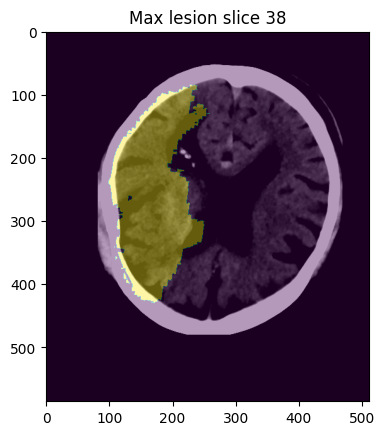

In [51]:
index = '411'

wl = 40
ww = 40

ct_image = sitk.ReadImage(os.path.join(imagesTr, f'{dataset_id}_{index}_0000.nii.gz'))
mask_image = sitk.ReadImage(os.path.join(labelsTr, f'{dataset_id}_{index}.nii.gz'))

ct_np = sitk.GetArrayFromImage(ct_image)      # (z,y,x)
mask_np = sitk.GetArrayFromImage(mask_image)  # (z,y,x)

# Find slices containing lesion
lesion_area_per_slice = mask_np.sum(axis=(1,2))
z = np.argmax(lesion_area_per_slice)
windowed_slice = apply_window(ct_np[z], wl, ww)

if lesion_area_per_slice[z] == 0:
    print("⚠️ Empty mask")
else:
    print(f"Showing slice {z} (largest lesion area)")
    
    plt.imshow(windowed_slice, cmap="gray")
    plt.imshow(mask_np[z], alpha=0.4)
    plt.title(f"Max lesion slice {z}")
    plt.show()

Showing slice 54 (largest lesion area)


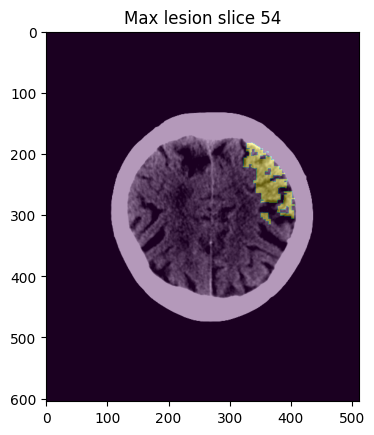

In [52]:
index = '420'

wl = 40
ww = 40

ct_image = sitk.ReadImage(os.path.join(imagesTr, f'{dataset_id}_{index}_0000.nii.gz'))
mask_image = sitk.ReadImage(os.path.join(labelsTr, f'{dataset_id}_{index}.nii.gz'))

ct_np = sitk.GetArrayFromImage(ct_image)      # (z,y,x)
mask_np = sitk.GetArrayFromImage(mask_image)  # (z,y,x)

# Find slices containing lesion
lesion_area_per_slice = mask_np.sum(axis=(1,2))
z = np.argmax(lesion_area_per_slice)
windowed_slice = apply_window(ct_np[z], wl, ww)

if lesion_area_per_slice[z] == 0:
    print("⚠️ Empty mask")
else:
    print(f"Showing slice {z} (largest lesion area)")
    
    plt.imshow(windowed_slice, cmap="gray")
    plt.imshow(mask_np[z], alpha=0.4)
    plt.title(f"Max lesion slice {z}")
    plt.show()

# DICE entre máscaras antes y después de acotar los valores

In [14]:
from scipy.spatial import distance

In [17]:
DICE = []
for idx, img_path in enumerate(os.listdir("D:/jm.rivera/ISLES24/raw_data/"), start=1):
    case_id = f"{dataset_id}_{(idx+i):03d}"
    mask_path = f"D:/jm.rivera/ISLES24/derivatives/sub-stroke{img_path[-4:]}/ses-02/sub-stroke{img_path[-4:]}_ses-02_space-ncct_lesion-msk.nii.gz"
    mask_path_new = os.path.join(labelsTr, f"{case_id}.nii.gz")

    mask_image = sitk.ReadImage(mask_path)
    mask_image_new = sitk.ReadImage(mask_path_new)

    mask_np = sitk.GetArrayFromImage(mask_image)      # (z,y,x)
    mask_new_np = sitk.GetArrayFromImage(mask_image_new)  # (z,y,x)

    DICE.append(1 - distance.dice(mask_np.flatten(), mask_new_np.flatten()))


d:\jm.rivera\stroke_venv\lib\site-packages\scipy\spatial\distance.py:1386: RuntimeWarning: invalid value encountered in divide
  return float((ntf + nft) / np.array(2.0 * ntt + ntf + nft))


In [50]:
idx = '0121'
case_id = f"{dataset_id}_{idx}"
mask_path = f"D:/jm.rivera/ISLES24/derivatives/sub-stroke{idx}/ses-02/sub-stroke{idx}_ses-02_space-ncct_lesion-msk.nii.gz"
mask_path_new = os.path.join(labelsTr, f"{case_id}.nii.gz")

mask_image = sitk.ReadImage(mask_path)
mask_image_new = sitk.ReadImage(mask_path_new)

mask_np = sitk.GetArrayFromImage(mask_image)      # (z,y,x)
mask_new_np = sitk.GetArrayFromImage(mask_image_new)  # (z,y,x)

print(1 - distance.dice(mask_np.flatten(), mask_new_np.flatten()))


RuntimeError: Exception thrown in SimpleITK ImageFileReader_Execute: D:\a\SimpleITK\SimpleITK\Code\IO\src\sitkImageReaderBase.cxx:91:
sitk::ERROR: The file "D:/jm.rivera/ISLES24/derivatives/sub-stroke0121/ses-02/sub-stroke0121_ses-02_space-ncct_lesion-msk.nii.gz" does not exist.

In [25]:
np.where(np.isnan(np.array(DICE)))

(array([101, 121], dtype=int64),)

In [24]:
np.array(DICE)

array([0.99962444, 0.99932968, 1.        , 1.        , 0.99968165,
       0.98834191, 0.99906914, 0.99996795, 0.99970025, 1.        ,
       0.99815437, 0.9989343 , 0.99981655, 0.99450677, 1.        ,
       0.99973151, 0.99986843, 1.        , 0.99781421, 0.99990838,
       0.9999833 , 0.9992909 , 1.        , 0.99573103, 0.98212653,
       0.99778966, 0.99309609, 0.99991976, 0.99847421, 1.        ,
       0.98939304, 1.        , 1.        , 1.        , 1.        ,
       1.        , 0.99946809, 1.        , 0.99992322, 1.        ,
       1.        , 1.        , 0.99774588, 1.        , 0.99868323,
       1.        , 0.99620666, 0.99953118, 1.        , 1.        ,
       1.        , 0.99509467, 1.        , 0.9948044 , 0.99940515,
       0.99974965, 0.99995249, 1.        , 1.        , 1.        ,
       1.        , 1.        , 0.99982758, 0.99997412, 1.        ,
       1.        , 0.9937096 , 1.        , 0.99992199, 0.99995634,
       1.        , 0.99628847, 1.        , 1.        , 0.99970